# EDA

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [5]:
demo = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name='Customer_Demographics')
trans = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name='Transaction_History')
service = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name='Customer_Service')
online = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name='Online_Activity')
churn = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name='Churn_Status')

In [6]:
# Merge all datasets
df = demo.merge(trans, on="CustomerID", how="left") \
         .merge(service, on="CustomerID", how="left") \
         .merge(online, on="CustomerID", how="left") \
         .merge(churn, on="CustomerID", how="left")

# Check the merged data
print(df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

   CustomerID  Age Gender MaritalStatus IncomeLevel  TransactionID  \
0           1   62      M        Single         Low           7194   
1           2   65      M       Married         Low           7250   
2           2   65      M       Married         Low           9660   
3           2   65      M       Married         Low           2998   
4           2   65      M       Married         Low           1228   

  TransactionDate  AmountSpent ProductCategory  InteractionID InteractionDate  \
0      2022-03-27       416.50     Electronics         6363.0      2022-03-31   
1      2022-08-08        54.96        Clothing         3329.0      2022-03-17   
2      2022-07-25       197.50     Electronics         3329.0      2022-03-17   
3      2022-01-25       101.31       Furniture         3329.0      2022-03-17   
4      2022-07-24       397.37        Clothing         3329.0      2022-03-17   

  InteractionType ResolutionStatus LastLoginDate  LoginFrequency ServiceUsage  \
0         I

In [9]:
df = df.dropna()

               Age  AmountSpent  LoginFrequency
count  5204.000000  5204.000000     5204.000000
mean     43.140085   254.354940       25.918332
std      15.430343   143.329654       14.110627
min      18.000000     5.180000        1.000000
25%      29.000000   128.940000       14.000000
50%      43.000000   255.175000       27.000000
75%      57.000000   378.605000       38.000000
max      69.000000   499.700000       49.000000


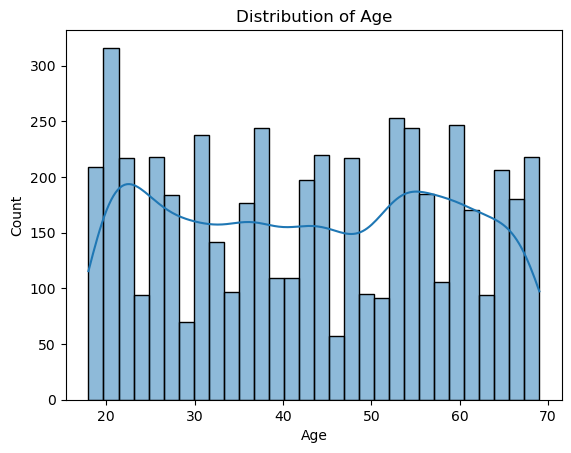

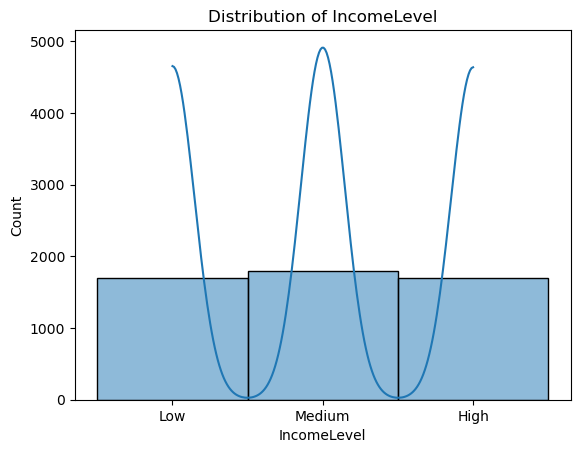

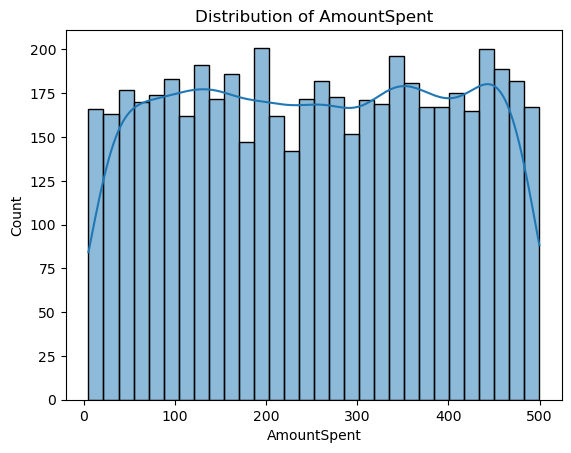

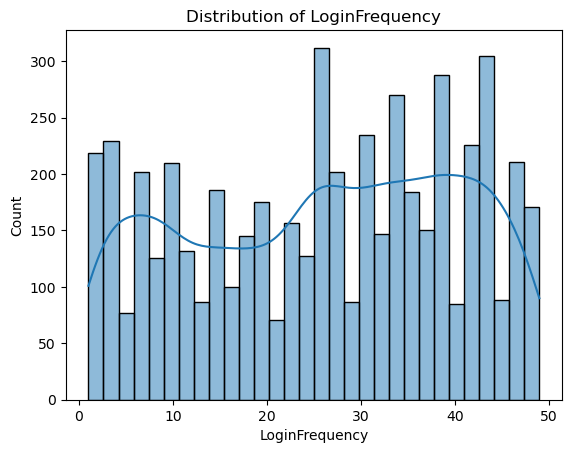

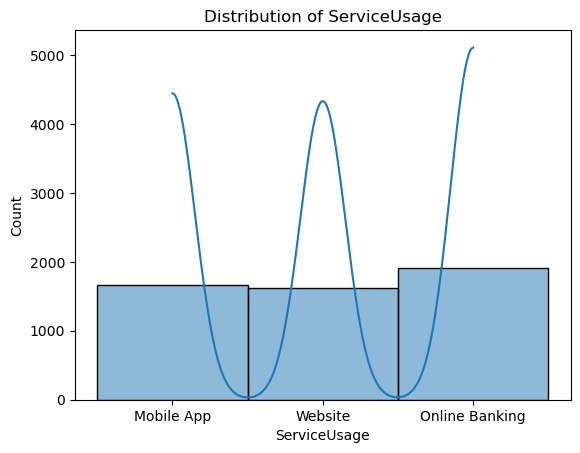

In [11]:
# Summary statistics for numerical columns
num_cols = ['Age', 'IncomeLevel', 'AmountSpent', 'LoginFrequency', 'ServiceUsage']
print(df[num_cols].describe())

# Check distributions
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

# Churn by Demographics

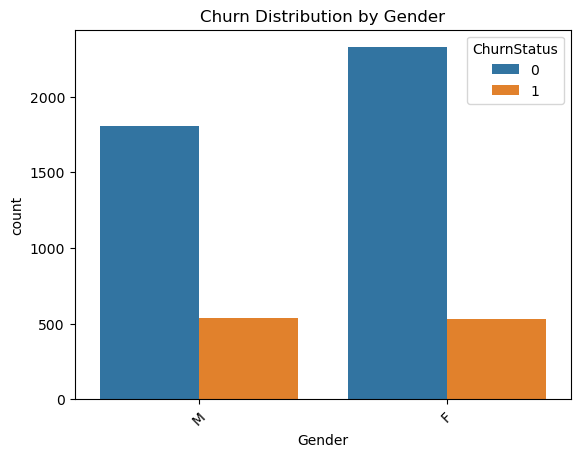

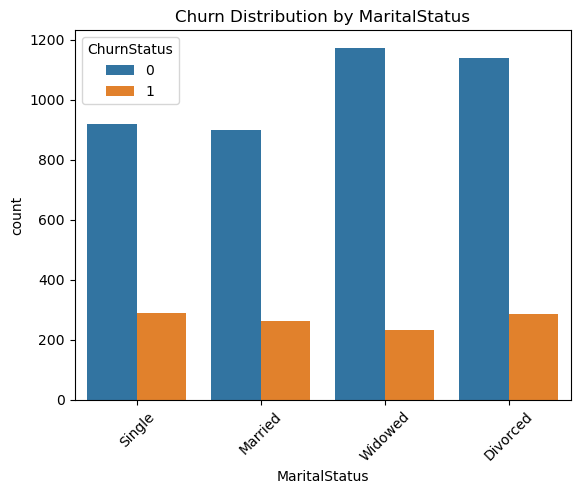

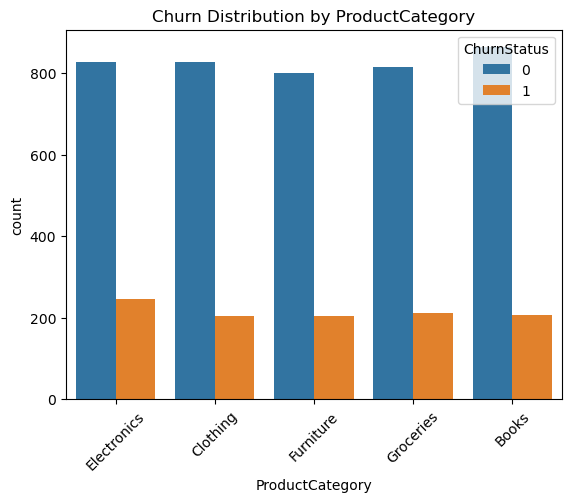

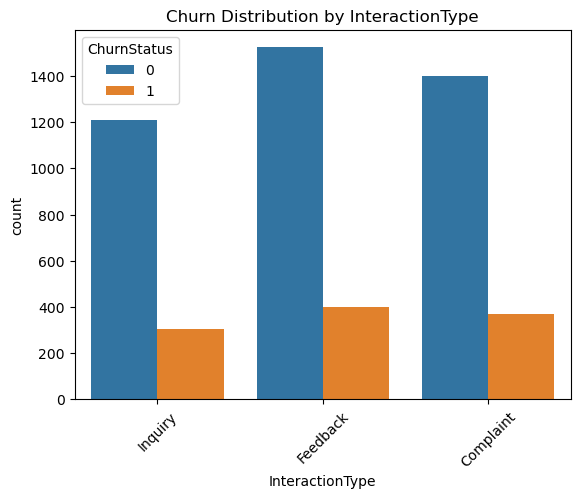

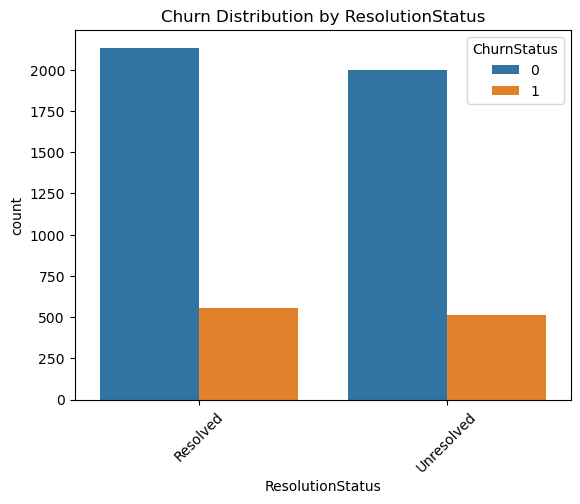

In [12]:
cat_cols = ['Gender', 'MaritalStatus', 'ProductCategory', 'InteractionType', 'ResolutionStatus']
for col in cat_cols:
    plt.figure()
    sns.countplot(data=df, x=col, hue='ChurnStatus')
    plt.title(f'Churn Distribution by {col}')
    plt.xticks(rotation=45)
    plt.show()

Churn Rate: 20.60%


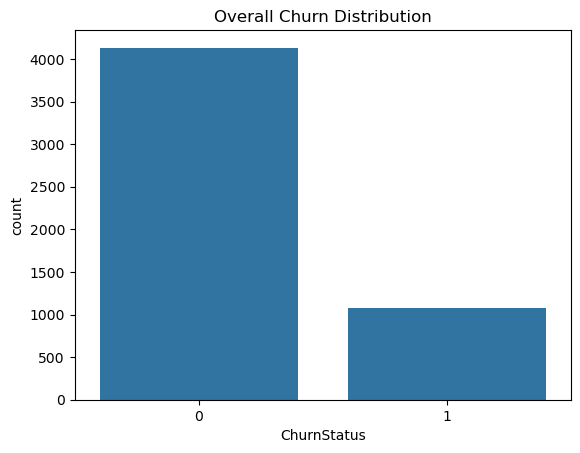

In [13]:
churn_rate = df['ChurnStatus'].value_counts(normalize=True) * 100
print(f"Churn Rate: {churn_rate[1]:.2f}%")

plt.figure()
sns.countplot(data=df, x='ChurnStatus')
plt.title("Overall Churn Distribution")
plt.show()

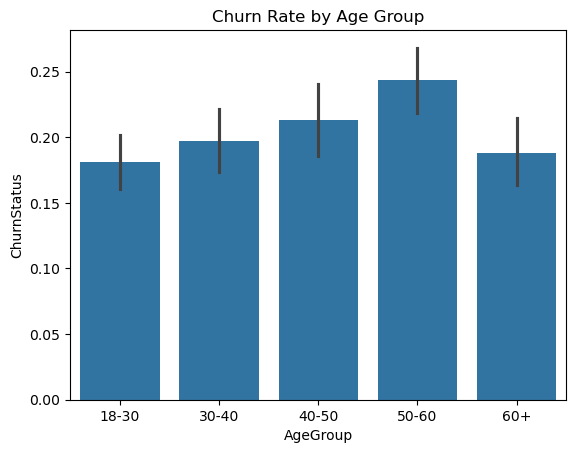

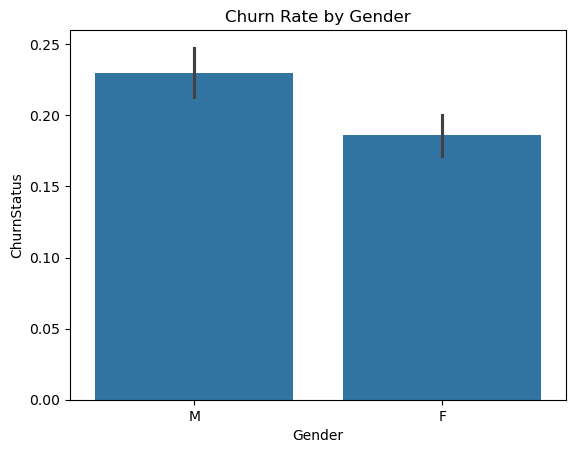

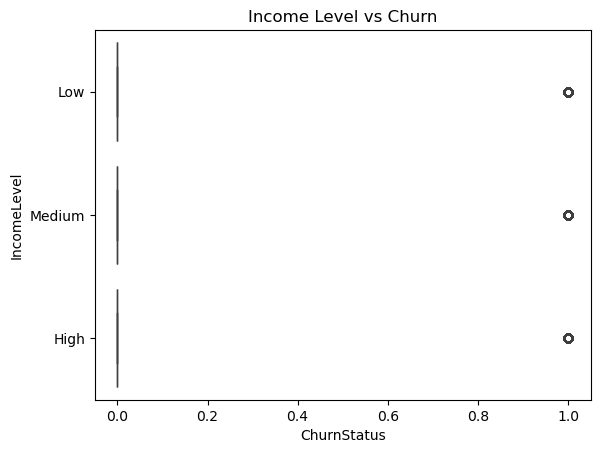

In [14]:
# Churn by Age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 100], labels=['18-30', '30-40', '40-50', '50-60', '60+'])
sns.barplot(data=df, x='AgeGroup', y='ChurnStatus', estimator=np.mean)
plt.title("Churn Rate by Age Group")
plt.show()

# Churn by Gender
sns.barplot(data=df, x='Gender', y='ChurnStatus', estimator=np.mean)
plt.title("Churn Rate by Gender")
plt.show()

# Churn by Income Level
sns.boxplot(data=df, x='ChurnStatus', y='IncomeLevel')
plt.title("Income Level vs Churn")
plt.show()

## Churn vs Spending Habits

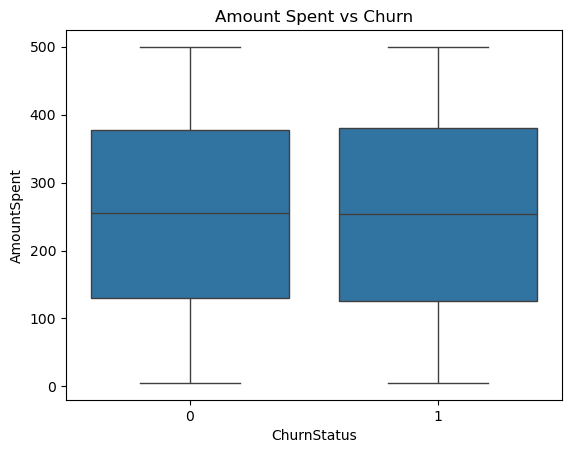

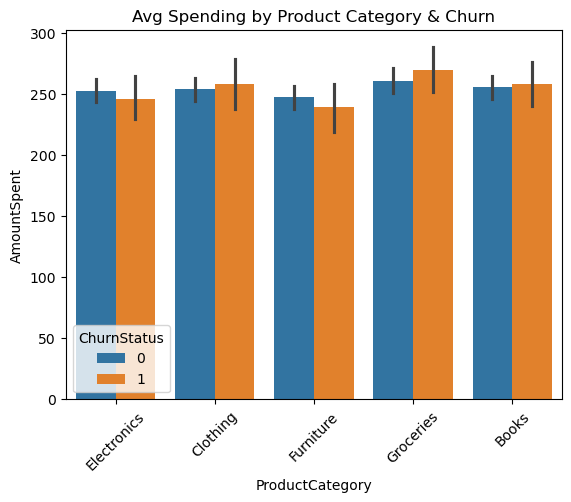

In [15]:
sns.boxplot(data=df, x='ChurnStatus', y='AmountSpent')
plt.title("Amount Spent vs Churn")
plt.show()

# Average spending per category for churned vs retained customers
sns.barplot(data=df, x='ProductCategory', y='AmountSpent', hue='ChurnStatus', estimator=np.mean)
plt.title("Avg Spending by Product Category & Churn")
plt.xticks(rotation=45)
plt.show()

# Churn vs Online Activity

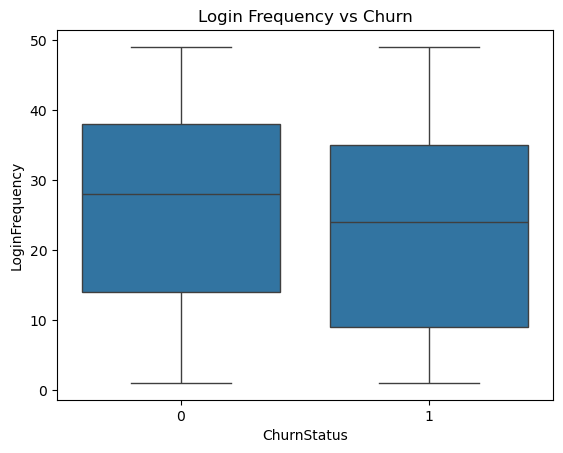

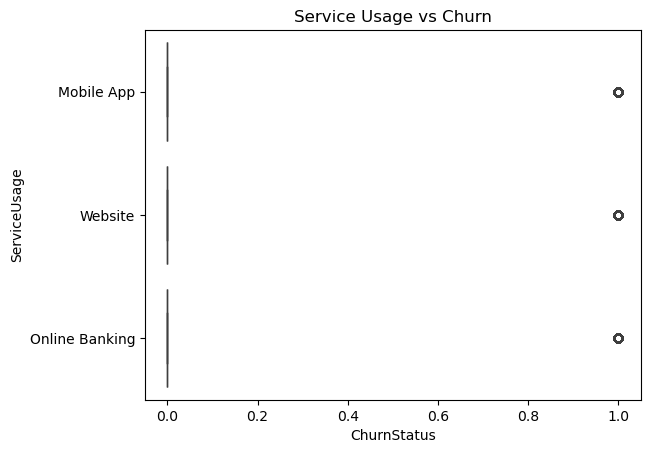

In [16]:
sns.boxplot(data=df, x='ChurnStatus', y='LoginFrequency')
plt.title("Login Frequency vs Churn")
plt.show()

sns.boxplot(data=df, x='ChurnStatus', y='ServiceUsage')
plt.title("Service Usage vs Churn")
plt.show()

# Churn vs Interaction Type

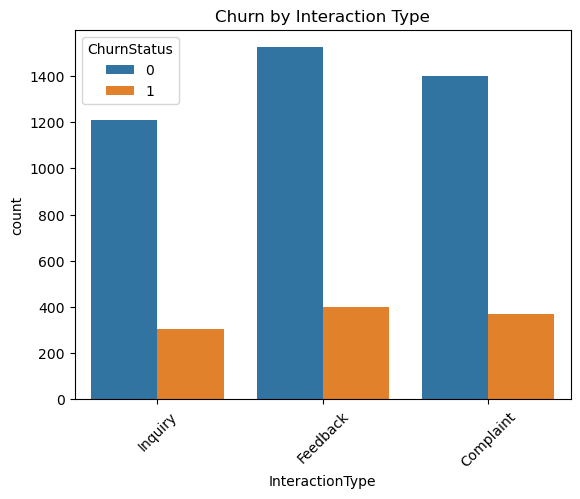

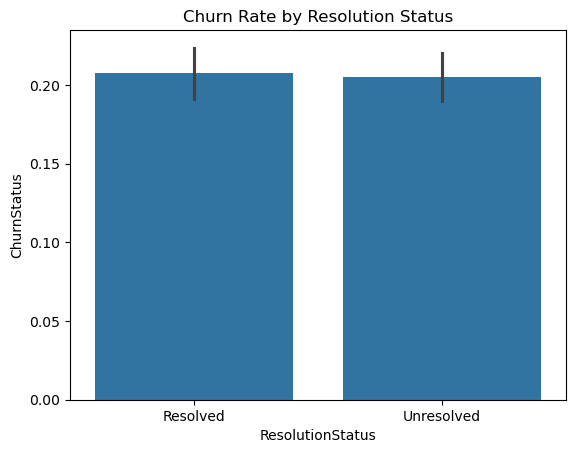

In [18]:
sns.countplot(data=df, x='InteractionType', hue='ChurnStatus')
plt.title("Churn by Interaction Type")
plt.xticks(rotation=45)
plt.show()

# Resolution status impact
sns.barplot(data=df, x='ResolutionStatus', y='ChurnStatus', estimator=np.mean)
plt.title("Churn Rate by Resolution Status")
plt.show()

# Correlation Analysis

In [23]:
print(df[num_cols])

      Age IncomeLevel  AmountSpent  LoginFrequency ServiceUsage
0      62         Low       416.50              34   Mobile App
1      65         Low        54.96               5      Website
2      65         Low       197.50               5      Website
3      65         Low       101.31               5      Website
4      65         Low       397.37               5      Website
...   ...         ...          ...             ...          ...
6788   23         Low       225.82              34      Website
6789   23         Low       494.90              34      Website
6790   23         Low       101.21              34      Website
6791   23         Low        73.91              34      Website
6792   23         Low       124.16              34      Website

[5204 rows x 5 columns]


In [25]:
numeric_col = df.select_dtypes(include=['int64','float64']).columns
print(numeric_col)

Index(['CustomerID', 'Age', 'TransactionID', 'AmountSpent', 'InteractionID',
       'LoginFrequency', 'ChurnStatus'],
      dtype='object')


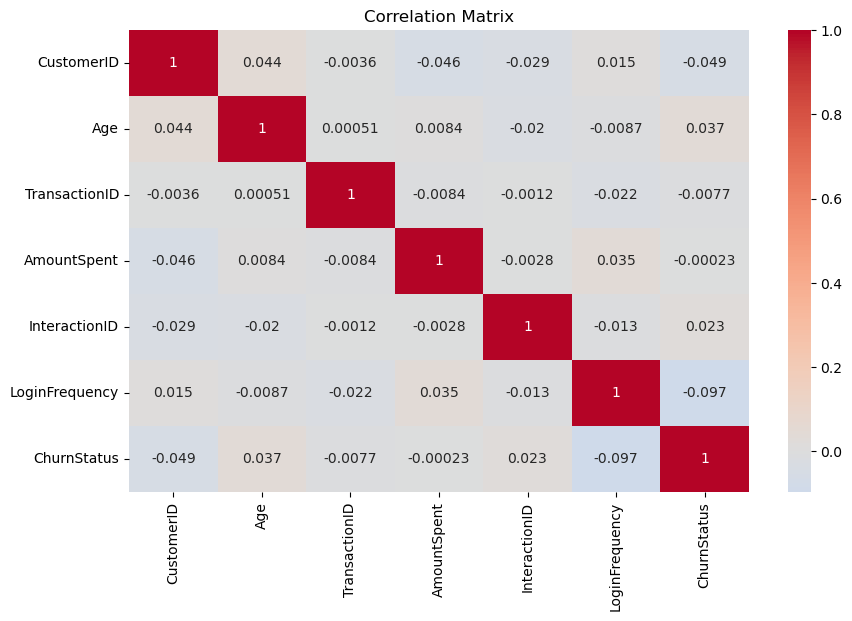

In [26]:

# Compute correlation matrix
corr = df[numeric_col].corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

# Feature Engineering for Customer Churn Prediction


### Time based Features

#### Days Since Last Activity

In [29]:
# Convert dates to datetime
df['LastLoginDate'] = pd.to_datetime(df['LastLoginDate'])
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['InteractionDate'] = pd.to_datetime(df['InteractionDate'])

# Days since last login
df['DaysSinceLastLogin'] = (datetime.now() - df['LastLoginDate']).dt.days

# Days since last transaction
df['DaysSinceLastTransaction'] = (datetime.now() - df['TransactionDate']).dt.days

#### Transaction Frequency

In [41]:
# Avg transactions per month (assuming data covers 12 months)
df['AvgTransactionsPerMonth'] = df.groupby('CustomerID')['TransactionID'].transform('count') / 12

## Behavioral Aggregates

In [48]:
# Avg Spending per Month
df['AvgSpendingPerMonth'] = df.groupby('CustomerID')['AmountSpent'].transform('sum') / 12

#### Complaint Ratio

In [43]:
# % of interactions that were complaints
df['ComplaintRatio'] = df.groupby('CustomerID')['InteractionType'].transform(
    lambda x: (x == 'Complaint').mean()
)

#### Resolution Success Rate

In [44]:
# % of resolved interactions
df['ResolutionSuccessRate'] = df.groupby('CustomerID')['ResolutionStatus'].transform(
    lambda x: (x == 'Resolved').mean()
)

## Derived Categorical Features

####  High-Risk Customer Segment

In [45]:
# Based on EDA insights
conditions = [
    (df['AgeGroup'].isin(['18-30'])) & (df['IncomeLevel'] == 'Low'),
    (df['MaritalStatus'].isin(['Divorced', 'Widowed'])),
    (df['ProductCategory'] == 'Electronics')
]
choices = ['High-Risk', 'Medium-Risk', 'Low-Risk']
df['RiskSegment'] = np.select(conditions, choices, default='Neutral')

#### Activity Tier

In [46]:
# Classify login frequency
df['ActivityTier'] = pd.cut(df['LoginFrequency'], 
                           bins=[0, 5, 10, np.inf], 
                           labels=['Low', 'Medium', 'High'])

## Feature Selection 

In [49]:
final_features = [
    'Age', 'Gender', 'MaritalStatus', 'IncomeLevel',
    'AvgSpendingPerMonth', 'DaysSinceLastLogin', 
    'DaysSinceLastTransaction', 'ComplaintRatio',
    'ResolutionSuccessRate', 'RiskSegment', 
    'ActivityTier', 'ChurnStatus'
]

df_final = df[final_features]

In [51]:
df_final.head()

,Age,AvgSpendingPerMonth,DaysSinceLastLogin,DaysSinceLastTransaction,ComplaintRatio,ResolutionSuccessRate,ChurnStatus,Gender_F,Gender_M,MaritalStatus_Divorced,...,IncomeLevel_High,IncomeLevel_Low,IncomeLevel_Medium,RiskSegment_High-Risk,RiskSegment_Low-Risk,RiskSegment_Medium-Risk,RiskSegment_Neutral,ActivityTier_Low,ActivityTier_Medium,ActivityTier_High
0,62,34.708333,665,1238,0.0,1.0,0,False,True,False,...,False,True,False,False,True,False,False,False,False,True
1,65,128.951667,620,1104,0.0,1.0,1,False,True,False,...,False,True,False,False,False,False,True,True,False,False
2,65,128.951667,620,1118,0.0,1.0,1,False,True,False,...,False,True,False,False,True,False,False,True,False,False
3,65,128.951667,620,1299,0.0,1.0,1,False,True,False,...,False,True,False,False,False,False,True,True,False,False
4,65,128.951667,620,1119,0.0,1.0,1,False,True,False,...,False,True,False,False,False,False,True,True,False,False


In [50]:
# One-hot encoding
df_final = pd.get_dummies(df_final, columns=['Gender', 'MaritalStatus', 'IncomeLevel', 'RiskSegment', 'ActivityTier'])

# Save for modeling
df_final.to_csv("engineered_customer_data.csv", index=False)
